# Notebook 2 — Fuel & Carbon Prices

Electricity prices are driven by **fuel costs**. This notebook explores the stochastic models that generate fuel and CO2 price paths:

1. **Ornstein-Uhlenbeck (O-U) process** — a mean-reverting random walk, ideal for commodity prices
2. **FuelPriceModel** (gas, coal) — O-U with scenario-dependent parameters
3. **ConstantFuelPrice** (uranium) — deterministic fallback
4. **CarbonPriceModel** — O-U for EU ETS CO2 prices
5. **SRMC computation** — how fuel prices become electricity costs
6. **Fuel-switching** — when coal beats gas (and vice versa)

**Runtime**: < 5 seconds

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from energy_sim.generators import FuelPriceModel, ConstantFuelPrice, CarbonPriceModel
from energy_sim.config import (
    GAS_SCENARIOS, COAL_SCENARIOS, CO2_SCENARIOS,
    QUARTERS_PER_YEAR, ITALIAN_MIX,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

N = QUARTERS_PER_YEAR  # 35,040 quarter-hours

## 1. The Ornstein-Uhlenbeck Process

Commodity prices don't behave like stock prices (random walk). Instead, they **revert to a mean** — when gas is expensive, suppliers ramp up, pushing prices down; when cheap, demand rises.

The O-U stochastic differential equation is:

$$dP = \theta (\mu - P)\, dt + \sigma\, dW$$

Where:
- $\mu$ = long-run mean price
- $\theta$ = mean-reversion speed (higher = faster snap-back)
- $\sigma$ = volatility
- $dW$ = Wiener process (random shocks)

Let's visualize what each parameter does:

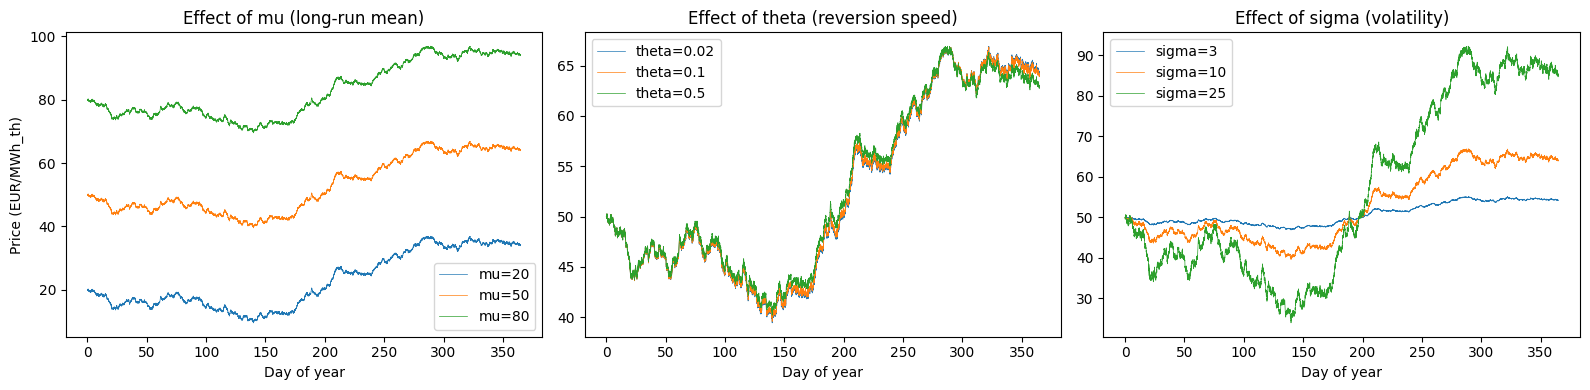

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Effect of mu
for mu in [20, 50, 80]:
    model = FuelPriceModel(mu=mu, sigma=10, theta=0.1)
    path = model.generate_path(N, np.random.default_rng(42))
    axes[0].plot(np.arange(N) / 96, path, lw=0.5, label=f'mu={mu}')
axes[0].set_title('Effect of mu (long-run mean)')
axes[0].set_xlabel('Day of year')
axes[0].set_ylabel('Price (EUR/MWh_th)')
axes[0].legend()

# Effect of theta (mean-reversion speed)
for theta in [0.02, 0.1, 0.5]:
    model = FuelPriceModel(mu=50, sigma=10, theta=theta)
    path = model.generate_path(N, np.random.default_rng(42))
    axes[1].plot(np.arange(N) / 96, path, lw=0.5, label=f'theta={theta}')
axes[1].set_title('Effect of theta (reversion speed)')
axes[1].set_xlabel('Day of year')
axes[1].legend()

# Effect of sigma (volatility)
for sigma in [3, 10, 25]:
    model = FuelPriceModel(mu=50, sigma=sigma, theta=0.1)
    path = model.generate_path(N, np.random.default_rng(42))
    axes[2].plot(np.arange(N) / 96, path, lw=0.5, label=f'sigma={sigma}')
axes[2].set_title('Effect of sigma (volatility)')
axes[2].set_xlabel('Day of year')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Gas Price Scenarios

The simulator defines three gas price scenarios reflecting different geopolitical conditions:

In [4]:
print("Gas scenarios (EUR/MWh_th):")
for name, params in GAS_SCENARIOS.items():
    print(f"  {name:>8s}: mu={params['mu']:5.1f}, sigma={params['sigma']:5.1f}, theta={params['theta']:.2f}")

print("\nCoal scenarios (EUR/MWh_th):")
for name, params in COAL_SCENARIOS.items():
    print(f"  {name:>8s}: mu={params['mu']:5.1f}, sigma={params['sigma']:5.1f}, theta={params['theta']:.2f}")

print("\nCO2 scenarios (EUR/ton):")
for name, params in CO2_SCENARIOS.items():
    print(f"  {name:>8s}: mu={params['mu']:5.1f}, sigma={params['sigma']:5.1f}, theta={params['theta']:.2f}")

Gas scenarios (EUR/MWh_th):
      base: mu= 35.0, sigma=  8.0, theta=0.10
   tension: mu= 55.0, sigma= 15.0, theta=0.10
    crisis: mu= 90.0, sigma= 25.0, theta=0.10

Coal scenarios (EUR/MWh_th):
      base: mu= 12.0, sigma=  3.0, theta=0.05
   tension: mu= 18.0, sigma=  5.0, theta=0.05
    crisis: mu= 25.0, sigma=  8.0, theta=0.05

CO2 scenarios (EUR/ton):
      base: mu= 65.0, sigma= 10.0, theta=0.05
       low: mu= 40.0, sigma=  8.0, theta=0.05
      high: mu=100.0, sigma= 15.0, theta=0.05


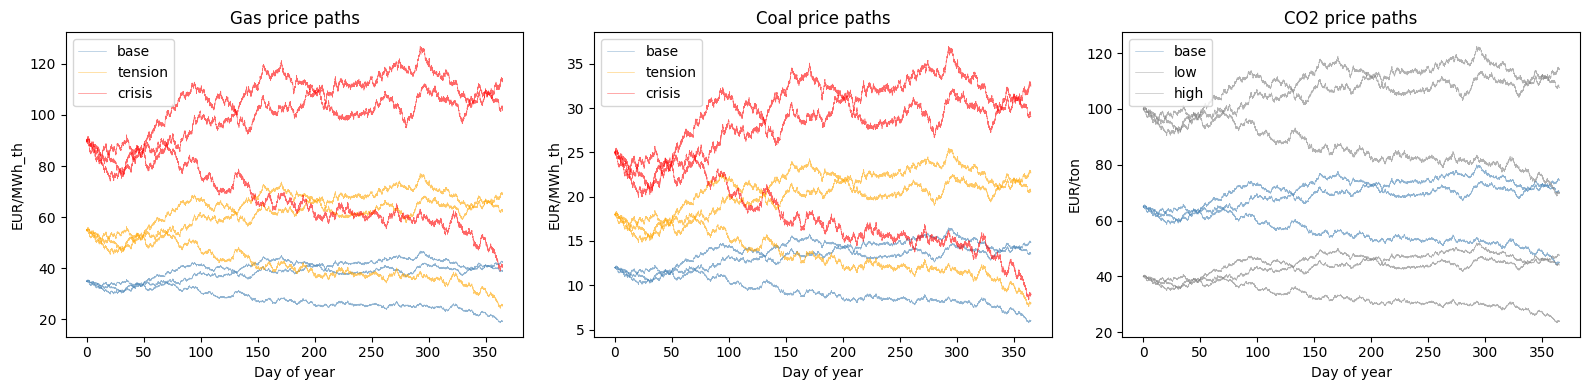

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
days = np.arange(N) / 96

colors = {'base': 'steelblue', 'tension': 'orange', 'crisis': 'red'}

# Multiple realizations per scenario
for ax, (scenarios, title, ylabel) in zip(axes, [
    (GAS_SCENARIOS, 'Gas price paths', 'EUR/MWh_th'),
    (COAL_SCENARIOS, 'Coal price paths', 'EUR/MWh_th'),
    (CO2_SCENARIOS, 'CO2 price paths', 'EUR/ton'),
]):
    for name, params in scenarios.items():
        if title.startswith('CO2'):
            model = CarbonPriceModel(**params)
        else:
            model = FuelPriceModel(**params)
        for seed in range(3):
            path = model.generate_path(N, np.random.default_rng(seed))
            ax.plot(days, path, lw=0.4, color=colors.get(name, 'gray'),
                    alpha=0.6, label=name if seed == 0 else None)
    ax.set_title(title)
    ax.set_xlabel('Day of year')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. From Fuel Price to Electricity Cost: SRMC

The **Short-Run Marginal Cost** (SRMC) is the cost of generating one additional MWh of electricity. For thermal plants:

$$\text{SRMC} = \frac{P_{\text{fuel}}}{\eta} + \frac{P_{\text{CO2}} \times e_f}{\eta} + C_{\text{VOM}}$$

Where:
- $P_{\text{fuel}}$ = fuel price (EUR/MWh_th)
- $\eta$ = thermal efficiency
- $P_{\text{CO2}}$ = carbon price (EUR/ton)
- $e_f$ = emission factor (tCO2/MWh_th)
- $C_{\text{VOM}}$ = variable O&M (EUR/MWh)

For renewables, SRMC = VOM only (no fuel cost).

In [6]:
# Compute SRMC for each technology at a given fuel/CO2 price
def compute_srmc(fuel_price, co2_price, efficiency, emission_factor, vom):
    """Compute SRMC in EUR/MWh_e."""
    fuel_comp = fuel_price / efficiency if efficiency < 1.0 else 0.0
    co2_comp = co2_price * emission_factor / efficiency if efficiency < 1.0 else 0.0
    return fuel_comp + co2_comp + vom

# Base case prices
gas_price = 35.0   # EUR/MWh_th (base scenario)
coal_price = 12.0  # EUR/MWh_th
co2_price = 65.0   # EUR/ton
uranium_price = 3.0  # EUR/MWh_th

techs = {
    'Gas': {'fuel': gas_price, 'eff': 0.58, 'ef': 0.20, 'vom': 3.0},
    'Coal': {'fuel': coal_price, 'eff': 0.40, 'ef': 0.34, 'vom': 4.0},
    'Nuclear': {'fuel': uranium_price, 'eff': 0.33, 'ef': 0.0, 'vom': 2.5},
    'Solar': {'fuel': 0, 'eff': 1.0, 'ef': 0.0, 'vom': 0.5},
    'Wind': {'fuel': 0, 'eff': 1.0, 'ef': 0.0, 'vom': 1.5},
    'Hydro': {'fuel': 0, 'eff': 1.0, 'ef': 0.0, 'vom': 0.0},
}

print(f"Fuel prices: gas={gas_price}, coal={coal_price}, CO2={co2_price} EUR/ton\n")
print(f"{'Technology':<10s} {'Fuel':>8s} {'CO2':>8s} {'VOM':>6s} {'SRMC':>8s}")
print("-" * 45)
for name, t in techs.items():
    fuel_comp = t['fuel'] / t['eff'] if t['eff'] < 1.0 else 0.0
    co2_comp = co2_price * t['ef'] / t['eff'] if t['eff'] < 1.0 else 0.0
    srmc = fuel_comp + co2_comp + t['vom']
    print(f"{name:<10s} {fuel_comp:8.1f} {co2_comp:8.1f} {t['vom']:6.1f} {srmc:8.1f} EUR/MWh")

Fuel prices: gas=35.0, coal=12.0, CO2=65.0 EUR/ton

Technology     Fuel      CO2    VOM     SRMC
---------------------------------------------
Gas            60.3     22.4    3.0     85.8 EUR/MWh
Coal           30.0     55.2    4.0     89.2 EUR/MWh
Nuclear         9.1      0.0    2.5     11.6 EUR/MWh
Solar           0.0      0.0    0.5      0.5 EUR/MWh
Wind            0.0      0.0    1.5      1.5 EUR/MWh
Hydro           0.0      0.0    0.0      0.0 EUR/MWh


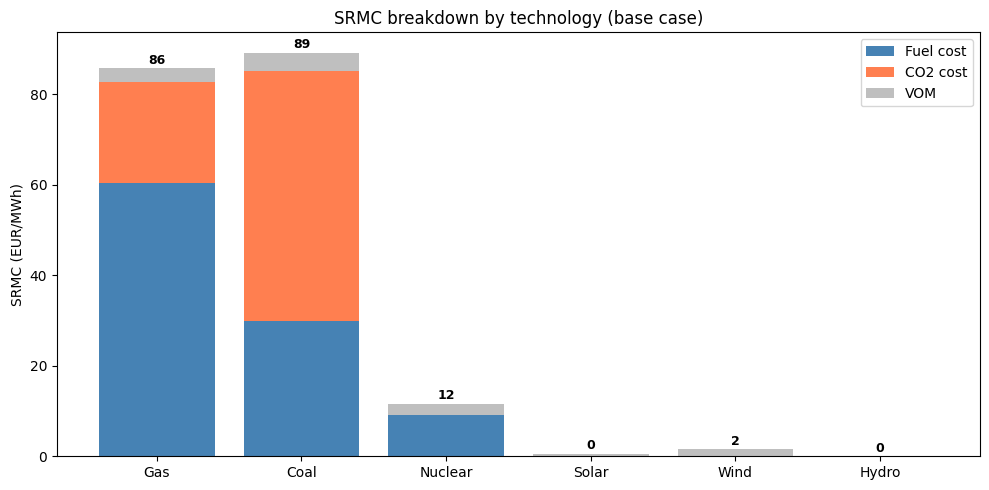

In [7]:
# Visualize SRMC breakdown as stacked bars
fig, ax = plt.subplots(figsize=(10, 5))

names = list(techs.keys())
fuel_comps = []
co2_comps = []
vom_comps = []

for t in techs.values():
    fuel_comps.append(t['fuel'] / t['eff'] if t['eff'] < 1.0 else 0.0)
    co2_comps.append(co2_price * t['ef'] / t['eff'] if t['eff'] < 1.0 else 0.0)
    vom_comps.append(t['vom'])

x = np.arange(len(names))
ax.bar(x, fuel_comps, label='Fuel cost', color='steelblue')
ax.bar(x, co2_comps, bottom=fuel_comps, label='CO2 cost', color='coral')
ax.bar(x, vom_comps, bottom=np.array(fuel_comps)+np.array(co2_comps),
       label='VOM', color='gray', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('SRMC (EUR/MWh)')
ax.set_title('SRMC breakdown by technology (base case)')
ax.legend()

# Add total labels
for i in range(len(names)):
    total = fuel_comps[i] + co2_comps[i] + vom_comps[i]
    ax.text(i, total + 1, f'{total:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Fuel-Switching: When Coal Beats Gas

Coal is cheaper per MWh_th than gas, but emits much more CO2. At high CO2 prices, coal's cost advantage disappears. The **crossover CO2 price** is where their SRMCs are equal.

$$P_{\text{CO2}}^* = \frac{P_{\text{gas}}/\eta_{\text{gas}} - P_{\text{coal}}/\eta_{\text{coal}}}{e_{\text{coal}}/\eta_{\text{coal}} - e_{\text{gas}}/\eta_{\text{gas}}}$$

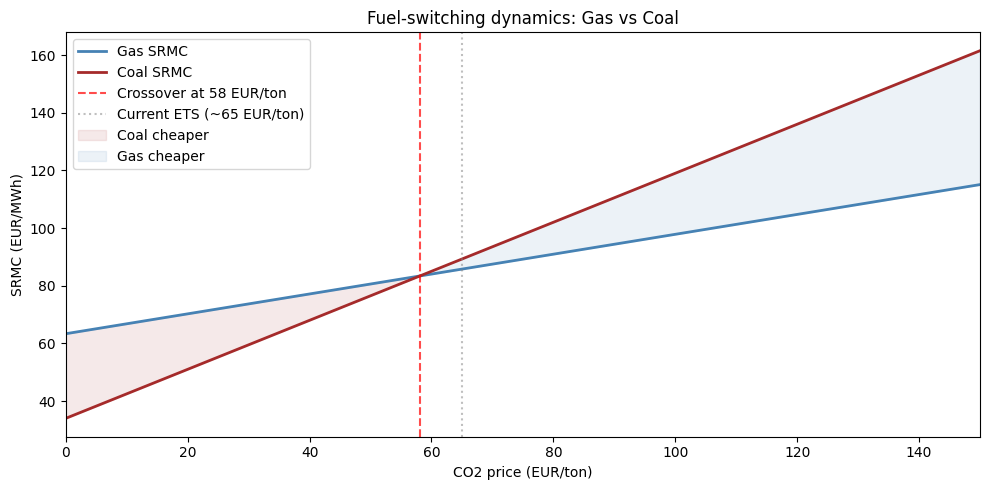

Fuel-switching CO2 price: ~58 EUR/ton
At current ETS (65 EUR/ton): gas SRMC = 85.8, coal SRMC = 89.2


In [8]:
co2_range = np.linspace(0, 150, 200)

gas_srmc = gas_price / 0.58 + co2_range * 0.20 / 0.58 + 3.0
coal_srmc = coal_price / 0.40 + co2_range * 0.34 / 0.40 + 4.0

# Find crossover
crossover_idx = np.argmin(np.abs(gas_srmc - coal_srmc))
crossover_co2 = co2_range[crossover_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(co2_range, gas_srmc, label='Gas SRMC', color='steelblue', lw=2)
ax.plot(co2_range, coal_srmc, label='Coal SRMC', color='brown', lw=2)
ax.axvline(crossover_co2, color='red', ls='--', alpha=0.7, label=f'Crossover at {crossover_co2:.0f} EUR/ton')
ax.axvline(65, color='gray', ls=':', alpha=0.5, label='Current ETS (~65 EUR/ton)')

ax.fill_between(co2_range, gas_srmc, coal_srmc,
                where=coal_srmc < gas_srmc, alpha=0.1, color='brown', label='Coal cheaper')
ax.fill_between(co2_range, gas_srmc, coal_srmc,
                where=gas_srmc < coal_srmc, alpha=0.1, color='steelblue', label='Gas cheaper')

ax.set_xlabel('CO2 price (EUR/ton)')
ax.set_ylabel('SRMC (EUR/MWh)')
ax.set_title('Fuel-switching dynamics: Gas vs Coal')
ax.legend(loc='upper left')
ax.set_xlim(0, 150)
plt.tight_layout()
plt.show()

print(f"Fuel-switching CO2 price: ~{crossover_co2:.0f} EUR/ton")
print(f"At current ETS ({65} EUR/ton): "
      f"gas SRMC = {gas_price/0.58 + 65*0.20/0.58 + 3:.1f}, "
      f"coal SRMC = {coal_price/0.40 + 65*0.34/0.40 + 4:.1f}")

## 5. Stochastic SRMC over a year

Because fuel and CO2 prices vary over time (O-U process), the SRMC is not constant — it fluctuates, and the merit order can shuffle at each timestep:

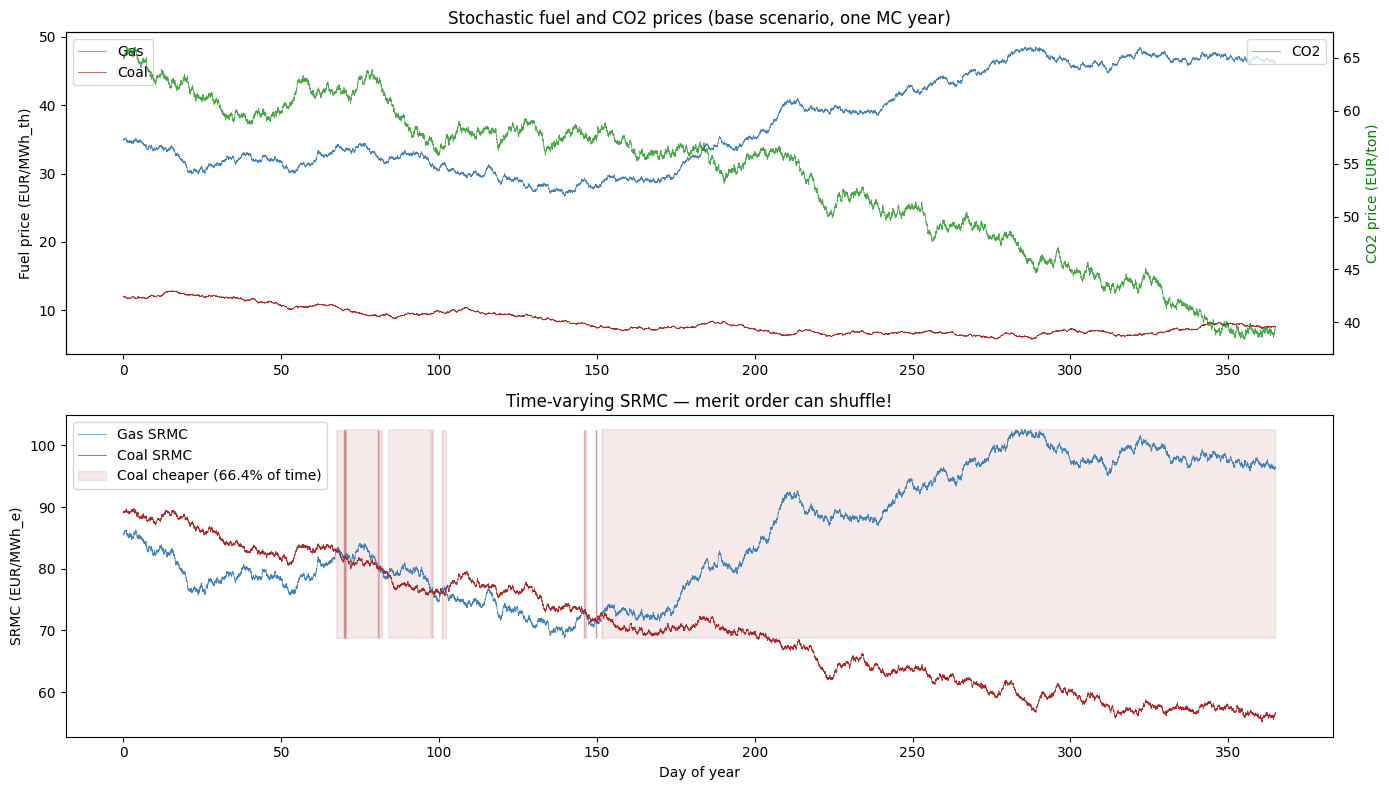

In [9]:
rng = np.random.default_rng(42)

gas_model = FuelPriceModel(**GAS_SCENARIOS['base'])
coal_model = FuelPriceModel(**COAL_SCENARIOS['base'])
co2_model = CarbonPriceModel(**CO2_SCENARIOS['base'])

gas_path = gas_model.generate_path(N, rng)
coal_path = coal_model.generate_path(N, rng)
co2_path = co2_model.generate_path(N, rng)

# Compute time-varying SRMC
srmc_gas = gas_path / 0.58 + co2_path * 0.20 / 0.58 + 3.0
srmc_coal = coal_path / 0.40 + co2_path * 0.34 / 0.40 + 4.0

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: fuel and CO2 prices
ax = axes[0]
ax.plot(days, gas_path, lw=0.5, label='Gas', color='steelblue')
ax.plot(days, coal_path, lw=0.5, label='Coal', color='brown')
ax2 = ax.twinx()
ax2.plot(days, co2_path, lw=0.5, label='CO2', color='green', alpha=0.7)
ax2.set_ylabel('CO2 price (EUR/ton)', color='green')
ax.set_ylabel('Fuel price (EUR/MWh_th)')
ax.set_title('Stochastic fuel and CO2 prices (base scenario, one MC year)')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# Bottom: time-varying SRMC
ax = axes[1]
ax.plot(days, srmc_gas, lw=0.5, label='Gas SRMC', color='steelblue')
ax.plot(days, srmc_coal, lw=0.5, label='Coal SRMC', color='brown')

# Highlight where coal is cheaper
coal_cheaper = srmc_coal < srmc_gas
ax.fill_between(days, srmc_gas.min(), srmc_gas.max(),
                where=coal_cheaper, alpha=0.1, color='brown',
                label=f'Coal cheaper ({coal_cheaper.mean()*100:.1f}% of time)')
ax.set_xlabel('Day of year')
ax.set_ylabel('SRMC (EUR/MWh_e)')
ax.set_title('Time-varying SRMC — merit order can shuffle!')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Play with parameters

Modify the fuel/CO2 parameters and observe how the SRMC landscape changes:

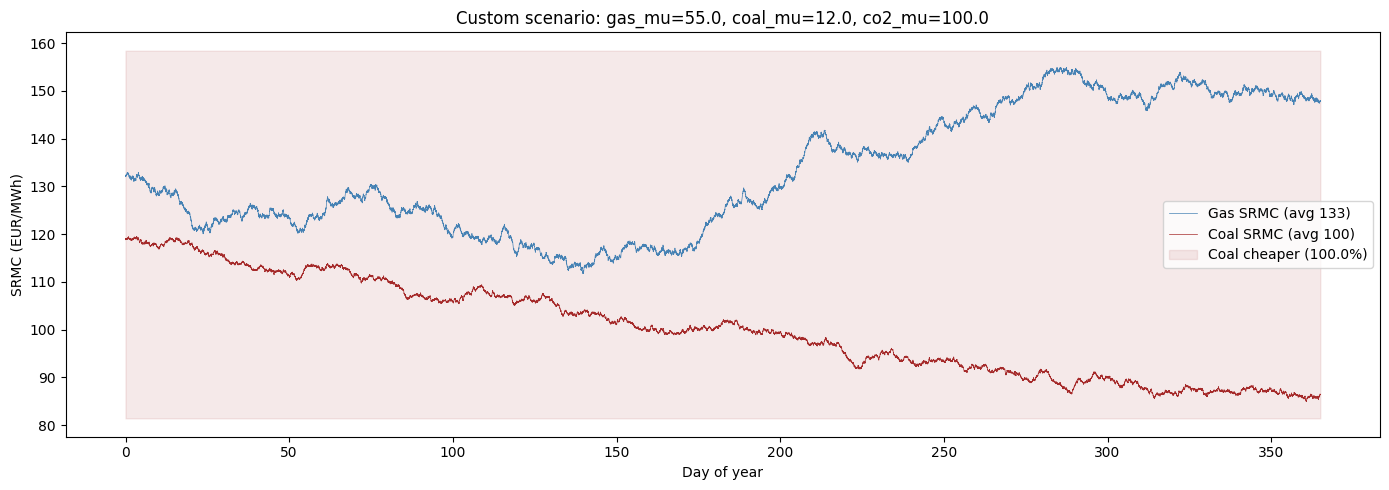

In [10]:
# ── PLAY WITH THESE ──────────────────────────────────────
custom_gas_mu = 55.0      # try 20-100 (tension = 55, crisis = 90)
custom_coal_mu = 12.0     # try 8-30
custom_co2_mu = 100.0     # try 30-150 (what happens at very high CO2?)
# ─────────────────────────────────────────────────────────

rng = np.random.default_rng(42)
gas_p = FuelPriceModel(mu=custom_gas_mu, sigma=10, theta=0.1).generate_path(N, rng)
coal_p = FuelPriceModel(mu=custom_coal_mu, sigma=3, theta=0.05).generate_path(N, rng)
co2_p = CarbonPriceModel(mu=custom_co2_mu, sigma=10, theta=0.05).generate_path(N, rng)

s_gas = gas_p / 0.58 + co2_p * 0.20 / 0.58 + 3.0
s_coal = coal_p / 0.40 + co2_p * 0.34 / 0.40 + 4.0

cheaper = s_coal < s_gas

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(days, s_gas, lw=0.5, label=f'Gas SRMC (avg {s_gas.mean():.0f})', color='steelblue')
ax.plot(days, s_coal, lw=0.5, label=f'Coal SRMC (avg {s_coal.mean():.0f})', color='brown')
ax.fill_between(days, ax.get_ylim()[0], ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 200,
                where=cheaper, alpha=0.1, color='brown',
                label=f'Coal cheaper ({cheaper.mean()*100:.1f}%)')
ax.set_xlabel('Day of year')
ax.set_ylabel('SRMC (EUR/MWh)')
ax.set_title(f'Custom scenario: gas_mu={custom_gas_mu}, coal_mu={custom_coal_mu}, co2_mu={custom_co2_mu}')
ax.legend()
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Mean-reversion** (O-U) is the right model for commodity prices — unlike stocks, fuel prices snap back to fundamentals.
2. **Three parameters** control the price dynamics: $\mu$ (level), $\theta$ (speed), $\sigma$ (volatility).
3. **SRMC** is the key dispatch metric — it determines merit-order position. For thermal plants, it depends on fuel price, efficiency, and CO2 cost.
4. **Fuel-switching** is a real phenomenon: at ~55 EUR/ton CO2, coal becomes more expensive than gas. The stochastic CO2 price creates timesteps where the merit order flips back and forth.
5. Renewables have near-zero SRMC (just VOM) — they always dispatch first when available.

**Next notebook**: [03 — Renewable Availability](./03_renewable_availability.ipynb) — how solar and wind availability profiles are generated.